# Publication figures, outline-driven v2

This notebook builds the main manuscript figures following `Paper_results_Outline 1.pdf`, with visual references from the SSRN paper and the current synthetic-data draft.

Current figure map:

- Figure 1: pictorial workflow schematic.
- Figure 2: CVAE PCA overlays for HIV, breast cancer, and diabetes.
- Figure 3: metric summary table plus grouped violin panels for discriminator AUC, TSTR F1, absolute utility gap, and basic distribution fidelity.
- Figure 4: multivariate biological structure using correlation heatmaps, absolute correlation differences, and correlation-preservation scatter.
- Figure 5: discriminator AUC versus controlled noise.
- Figure 6: reverse feature ablation with repeated RF separability distributions.

Supplementary candidates:

- PCA overlays for non-CVAE generators.
- Marginal feature violins and feature-shift/KLD diagnostics supporting Figure 3.
- F1 score versus noise using the same layout as Figure 5.


## Run settings

Use `RUN_MODE = "preview"` when you only want to check layout and styling quickly. Switch to `RUN_MODE = "final"` for manuscript-quality repeated runs. You can also override any individual count directly in the first code cell.


In [ ]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyreadr
from IPython.display import display, Markdown
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, FancyBboxPatch, Rectangle
from scipy.stats import chi2, entropy, ttest_ind
from sklearn.datasets import load_breast_cancer, fetch_openml, load_diabetes
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parents[1]

pkg_root = repo_root / "data_synthesis"
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

from models.bootstrap import sample_bootstrap
from models.cvae import sample_cvae, train_cvae, sample_trained_cvae
from models.gmm import sample_gmm
from models.iid_columnwise import sample_columnwise
from util.config import Config
from rfhack.core.rf_wrapper import RFWrapper

SEED = 42

# Toggle this first when iterating on visual style.
# Use "preview" for quick layout checks and "final" for manuscript runs.
RUN_MODE = "final"

RUN_PRESETS = {
    "preview": {
        "CVAE_EPOCHS": 10,
        "AUC_REPEATS": 5,
        "TSTR_REPEATS": 3,
        "ABLATION_REPEATS": 3,
        "NOISE_REPEATS": 2,
        "PROBE_SIGMAS": [0.0, 0.2, 0.5, 1.0],
    },
    "final": {
        "CVAE_EPOCHS": 200,
        "AUC_REPEATS": 50,
        "TSTR_REPEATS": 20,
        "ABLATION_REPEATS": 20,
        "NOISE_REPEATS": 5,
        "PROBE_SIGMAS": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0],
    },
}

if RUN_MODE not in RUN_PRESETS:
    raise ValueError(f"RUN_MODE must be one of {list(RUN_PRESETS)}")

_run_cfg = RUN_PRESETS[RUN_MODE]
CVAE_EPOCHS = _run_cfg["CVAE_EPOCHS"]
AUC_REPEATS = _run_cfg["AUC_REPEATS"]
TSTR_REPEATS = _run_cfg["TSTR_REPEATS"]
ABLATION_REPEATS = _run_cfg["ABLATION_REPEATS"]
NOISE_REPEATS = _run_cfg["NOISE_REPEATS"]
PROBE_SIGMAS = _run_cfg["PROBE_SIGMAS"]
NOISE_FRAC = 0.3

# Optional one-off overrides while designing figures. Leave as None to use the selected preset.
OVERRIDE_CVAE_EPOCHS = None
OVERRIDE_AUC_REPEATS = None
OVERRIDE_TSTR_REPEATS = None
OVERRIDE_ABLATION_REPEATS = None
OVERRIDE_NOISE_REPEATS = None
OVERRIDE_PROBE_SIGMAS = None

CVAE_EPOCHS = OVERRIDE_CVAE_EPOCHS or CVAE_EPOCHS
AUC_REPEATS = OVERRIDE_AUC_REPEATS or AUC_REPEATS
TSTR_REPEATS = OVERRIDE_TSTR_REPEATS or TSTR_REPEATS
ABLATION_REPEATS = OVERRIDE_ABLATION_REPEATS or ABLATION_REPEATS
NOISE_REPEATS = OVERRIDE_NOISE_REPEATS or NOISE_REPEATS
PROBE_SIGMAS = OVERRIDE_PROBE_SIGMAS or PROBE_SIGMAS

DATASET_ORDER = ["HIV", "Breast Cancer", "Diabetes"]
DATASET_COLORS = {"HIV": "#EA5C1F", "Breast Cancer": "#1DB100", "Diabetes": "#0076BA"}
DATASET_MARKERS = {"HIV": "^", "Breast Cancer": "o", "Diabetes": "s"}
METHOD_ORDER = ["Bootstrap", "Column-wise", "GMM", "CVAE"]
METHOD_COLORS = {"Bootstrap": "#6A5ACD", "Column-wise": "#CC79A7", "GMM": "#009E73", "CVAE": "#D55E00"}
METHOD_PASTELS = {"Bootstrap": "#C7C2F4", "Column-wise": "#E8B4D2", "GMM": "#A8DEC9", "CVAE": "#F2B49B"}
REAL_BLUE = "#9ECAE1"
SYN_RED = "#F4A6A6"
REAL_GREY = "#333434"
CVAE_ORANGE = "#D55E00"
LABEL_RED = "#C62828"
NEUTRAL = "#333434"

METHODS = {
    "Bootstrap": sample_bootstrap,
    "Column-wise": sample_columnwise,
    "GMM": sample_gmm,
    "CVAE": sample_cvae,
}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "axes.linewidth": 2.2,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "lines.linewidth": 3.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

print(f"Repository root: {repo_root}")
print(f"Run mode: {RUN_MODE} | CVAE_EPOCHS={CVAE_EPOCHS}, AUC_REPEATS={AUC_REPEATS}, TSTR_REPEATS={TSTR_REPEATS}, ABLATION_REPEATS={ABLATION_REPEATS}, NOISE_REPEATS={NOISE_REPEATS}")


Repository root: c:\Users\tonyt\Desktop\distinguishable_data
Run mode: preview | CVAE_EPOCHS=10, AUC_REPEATS=5, TSTR_REPEATS=3, ABLATION_REPEATS=3, NOISE_REPEATS=2


## Data loaders and synthetic samplers

The HIV loader reads only the real `x` and `y` objects. Synthetic data are generated fresh from the four local generator implementations.


In [161]:
def _to_numpy_X(X):
    return np.asarray(X.values if hasattr(X, "values") else X, dtype=np.float32)


def _to_numpy_y(y):
    y = np.asarray(y.values if hasattr(y, "values") else y).reshape(-1)
    if y.dtype.kind in {"i", "u", "b"}:
        return y.astype(int)
    return LabelEncoder().fit_transform(y).astype(int)


def load_hiv():
    rdata_path = repo_root / "data_synthesis" / "data" / "allSyntheticData.RData"
    obj = pyreadr.read_r(str(rdata_path))
    x_df = obj["x"]
    y_df = obj["y"]
    return {
        "dataset": "HIV",
        "X": _to_numpy_X(x_df),
        "y": _to_numpy_y(y_df),
        "feature_names": list(x_df.columns),
    }


def load_breast():
    raw = load_breast_cancer()
    return {
        "dataset": "Breast Cancer",
        "X": _to_numpy_X(raw.data),
        "y": _to_numpy_y(raw.target),
        "feature_names": list(raw.feature_names),
    }


def load_diabetes_dataset():
    try:
        raw = fetch_openml("diabetes", version=1, as_frame=False)
        return {
            "dataset": "Diabetes",
            "X": _to_numpy_X(raw.data),
            "y": _to_numpy_y(raw.target),
            "feature_names": list(raw.feature_names),
        }
    except Exception as exc:
        print(f"[fallback] OpenML diabetes unavailable ({exc}); using sklearn diabetes binarized at median target.")
        raw = load_diabetes()
        y = (raw.target >= np.median(raw.target)).astype(int)
        return {
            "dataset": "Diabetes",
            "X": _to_numpy_X(raw.data),
            "y": y,
            "feature_names": list(raw.feature_names),
        }


LOADERS = {"HIV": load_hiv, "Breast Cancer": load_breast, "Diabetes": load_diabetes_dataset}


def load_datasets():
    out = {}
    for name in DATASET_ORDER:
        out[name] = LOADERS[name]()
    return out


def class_counts(y):
    y = np.asarray(y).astype(int)
    return int(np.sum(y == 0)), int(np.sum(y == 1))


def sample_synthetic(dataset, data, method, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    X = np.asarray(data["X"], dtype=np.float32)
    y = np.asarray(data["y"], dtype=int)
    n0, n1 = class_counts(y)
    if method == "CVAE":
        cfg = Config(seed=seed, epochs=cvae_epochs)
        return sample_cvae(X, y, n0, n1, seed=seed, cfg=cfg)
    return METHODS[method](X, y, n0, n1, seed=seed)


def standardize_pair(X_real, X_syn):
    scaler = StandardScaler()
    Xr = scaler.fit_transform(np.asarray(X_real, dtype=np.float64))
    Xs = scaler.transform(np.asarray(X_syn, dtype=np.float64))
    return Xr, Xs


def clean_axis(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    if grid_axis:
        ax.grid(axis=grid_axis, color="#D9D9D9", linewidth=0.8, alpha=0.45)
    else:
        ax.grid(False)


def add_panel_label(ax, label, color=NEUTRAL):
    ax.text(-0.12, 1.08, label, transform=ax.transAxes, ha="left", va="top", fontsize=18, weight="bold", color=color)


def add_confidence_ellipse(ax, xy, color, linestyle="-", linewidth=2.0):
    xy = np.asarray(xy, dtype=float)
    if xy.shape[0] < 3:
        return
    cov = np.cov(xy, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    scale = np.sqrt(chi2.ppf(0.95, df=2))
    width, height = 2 * scale * np.sqrt(vals)
    ax.add_patch(Ellipse(xy.mean(axis=0), width=width, height=height, angle=angle,
                         facecolor="none", edgecolor=color, linewidth=linewidth, linestyle=linestyle))


datasets = load_datasets()
summary = pd.DataFrame([
    {
        "dataset": name,
        "samples": len(data["y"]),
        "features": np.asarray(data["X"]).shape[1],
        "class_0": int((np.asarray(data["y"]) == 0).sum()),
        "class_1": int((np.asarray(data["y"]) == 1).sum()),
    }
    for name, data in datasets.items()
])
summary


,dataset,samples,features,class_0,class_1
0,HIV,91,63,23,68
1,Breast Cancer,569,30,212,357
2,Diabetes,768,8,500,268


## Figure 1 - schematic workflow

This schematic uses icon-like mini panels: matrices for input data, generator archetypes, distinct metric thumbnails, and explicit stress-test thumbnails for noise and feature ablation.


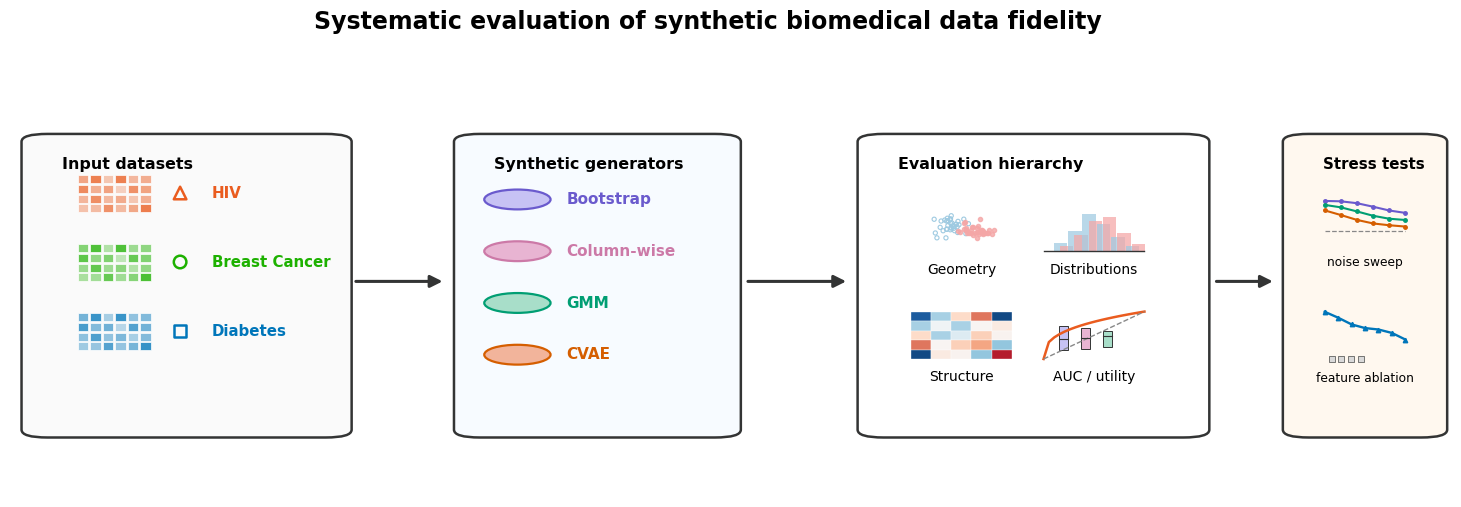

In [162]:
def _mini_matrix(ax, x, y, w, h, color):
    rng = np.random.default_rng(1)
    vals = rng.random((4, 6))
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            fc = mpl.colors.to_rgba(color, 0.25 + 0.55 * vals[i, j])
            ax.add_patch(Rectangle((x + j*w/6, y + (3-i)*h/4), w/6*0.86, h/4*0.82,
                                   facecolor=fc, edgecolor="white", linewidth=0.5, transform=ax.transAxes))


def _mini_pca(ax, x, y, w, h):
    rng = np.random.default_rng(2)
    a = rng.normal([0.38, 0.55], [0.08, 0.11], size=(35, 2))
    b = rng.normal([0.62, 0.45], [0.10, 0.09], size=(35, 2))
    ax.scatter(x + a[:, 0]*w, y + a[:, 1]*h, s=9, facecolors="none", edgecolors=REAL_BLUE, linewidths=0.8, transform=ax.transAxes)
    ax.scatter(x + b[:, 0]*w, y + b[:, 1]*h, s=9, color=SYN_RED, alpha=0.8, transform=ax.transAxes)


def _mini_heat(ax, x, y, w, h):
    rng = np.random.default_rng(3)
    mat = rng.random((5, 5))
    mat = (mat + mat.T) / 2
    for i in range(5):
        for j in range(5):
            ax.add_patch(Rectangle((x + j*w/5, y + (4-i)*h/5), w/5, h/5,
                                   facecolor=plt.cm.RdBu_r(mat[i, j]), edgecolor="white", linewidth=0.25,
                                   transform=ax.transAxes))


def _mini_distribution(ax, x, y, w, h):
    heights_real = np.array([0.18, 0.42, 0.78, 0.58, 0.30, 0.12])
    heights_syn = np.array([0.12, 0.35, 0.64, 0.72, 0.38, 0.16])
    bw = w / 7.5
    for i, (hr, hs) in enumerate(zip(heights_real, heights_syn)):
        xx = x + (i + 0.7) * w / 7
        ax.add_patch(Rectangle((xx, y), bw, h*hr, facecolor=REAL_BLUE, edgecolor="none", alpha=0.72, transform=ax.transAxes))
        ax.add_patch(Rectangle((xx + bw*0.45, y), bw, h*hs, facecolor=SYN_RED, edgecolor="none", alpha=0.72, transform=ax.transAxes))
    ax.plot([x, x+w], [y, y], color=NEUTRAL, lw=1.0, transform=ax.transAxes)


def _mini_auc(ax, x, y, w, h):
    xs = np.linspace(0, 1, 20)
    ax.plot(x + xs*w, y + (xs**0.35)*h, color=DATASET_COLORS["HIV"], lw=1.8, transform=ax.transAxes)
    ax.plot([x, x+w], [y, y+h], color="#888888", lw=1.0, linestyle="--", transform=ax.transAxes)
    for i, c in enumerate([METHOD_PASTELS[m] for m in METHOD_ORDER[:3]]):
        xx = x + (0.15 + i*0.22) * w
        q1, q2, q3 = y + h*(0.18+i*0.04), y + h*(0.42+i*0.03), y + h*(0.70-i*0.05)
        ax.add_patch(Rectangle((xx, q1), w*0.09, q3-q1, facecolor=c, edgecolor=NEUTRAL, lw=0.7, transform=ax.transAxes))
        ax.plot([xx, xx+w*0.09], [q2, q2], color=NEUTRAL, lw=0.8, transform=ax.transAxes)


def _mini_noise(ax, x, y, w, h):
    xs = np.linspace(0, 1, 6)
    for j, method in enumerate(["Bootstrap", "GMM", "CVAE"]):
        ys = 0.82 - 0.10*j - (0.18 + 0.05*j)*xs + 0.035*np.sin(5*xs + j)
        ax.plot(x + xs*w, y + ys*h, color=METHOD_COLORS[method], lw=1.5, marker="o", markersize=2.5, transform=ax.transAxes)
    ax.plot([x, x+w], [y+h*0.28, y+h*0.28], color="#888888", lw=0.9, linestyle="--", transform=ax.transAxes)
    ax.text(x + w*0.50, y - h*0.16, "noise sweep", ha="center", va="top", fontsize=8.8, transform=ax.transAxes)


def _mini_ablation(ax, x, y, w, h):
    xs = np.linspace(0, 1, 7)
    ys = 0.88 - 0.45*xs + 0.04*np.cos(8*xs)
    ax.plot(x + xs*w, y + ys*h, color=DATASET_COLORS["Diabetes"], lw=1.7, marker="^", markersize=3.2, transform=ax.transAxes)
    for i in range(4):
        ax.add_patch(Rectangle((x + (0.05 + i*0.12)*w, y + h*0.03), w*0.075, h*0.10,
                               facecolor="#D9D9D9", edgecolor=NEUTRAL, lw=0.45, transform=ax.transAxes))
    ax.text(x + w*0.50, y - h*0.16, "feature ablation", ha="center", va="top", fontsize=8.8, transform=ax.transAxes)


def _workflow_box(ax, x, y, w, h, title, color="#FFFFFF", title_size=11.4):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012,rounding_size=0.018",
                                linewidth=1.8, edgecolor=NEUTRAL, facecolor=color, transform=ax.transAxes))
    ax.text(x + 0.016, y + h - 0.04, title, transform=ax.transAxes, ha="left", va="top", weight="bold", fontsize=title_size)


def plot_figure1_workflow():
    fig, ax = plt.subplots(figsize=(18.6, 5.6))
    ax.set_axis_off()
    fig.suptitle("Systematic evaluation of synthetic biomedical data fidelity", y=0.98, fontsize=17, weight="bold")

    _workflow_box(ax, 0.020, 0.15, 0.205, 0.68, "Input datasets", "#FAFAFA")
    for i, ds in enumerate(DATASET_ORDER):
        y = 0.66 - i*0.16
        _mini_matrix(ax, 0.047, y, 0.052, 0.09, DATASET_COLORS[ds])
        ax.scatter([0.118], [y+0.045], marker=DATASET_MARKERS[ds], s=82, facecolors="none", edgecolors=DATASET_COLORS[ds], linewidths=1.8, transform=ax.transAxes)
        ax.text(0.140, y+0.045, ds, transform=ax.transAxes, va="center", fontsize=10.8, color=DATASET_COLORS[ds], weight="bold")

    _workflow_box(ax, 0.320, 0.15, 0.175, 0.68, "Synthetic generators", "#F7FBFF")
    for i, method in enumerate(METHOD_ORDER):
        y = 0.69 - i*0.12
        ax.add_patch(Circle((0.352, y), 0.023, facecolor=METHOD_PASTELS[method], edgecolor=METHOD_COLORS[method], lw=1.6, transform=ax.transAxes))
        ax.text(0.386, y, method, transform=ax.transAxes, va="center", fontsize=11.0, color=METHOD_COLORS[method], weight="bold")

    _workflow_box(ax, 0.600, 0.15, 0.220, 0.68, "Evaluation hierarchy", "#FFFFFF")
    mini_specs = [("Geometry", _mini_pca), ("Distributions", _mini_distribution), ("Structure", _mini_heat), ("AUC / utility", _mini_auc)]
    for i, (label, drawer) in enumerate(mini_specs):
        xx = 0.625 + (i % 2) * 0.092
        yy = 0.57 - (i // 2) * 0.25
        drawer(ax, xx, yy, 0.070, 0.11)
        ax.text(xx + 0.035, yy - 0.026, label, transform=ax.transAxes, ha="center", va="top", fontsize=10.0)

    _workflow_box(ax, 0.895, 0.15, 0.090, 0.68, "Stress tests", "#FFF8EF", title_size=10.8)
    _mini_noise(ax, 0.912, 0.58, 0.056, 0.13)
    _mini_ablation(ax, 0.912, 0.31, 0.056, 0.13)

    arrow_specs = [
        (0.238, 0.302),
        (0.510, 0.582),
        (0.835, 0.878),
    ]
    for x0, x1 in arrow_specs:
        ax.add_patch(FancyArrowPatch((x0, 0.50), (x1, 0.50), arrowstyle="-|>", mutation_scale=18,
                                     linewidth=2.2, color=NEUTRAL, transform=ax.transAxes, clip_on=False))
    plt.show()

plot_figure1_workflow()


## Figure 2 - CVAE PCA overlays

Each panel compares real data with CVAE-generated synthetic data in PCA space using 95% ellipses. Real samples are grey; synthetic samples use the dataset color because the synthetic device is the comparison of interest. Dataset titles sit above each panel, and `n`/`p` are shown inside the plot.


In [ ]:
def plot_figure2_cvae_pca(datasets, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.85))
    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        X_syn, _ = sample_synthetic(ds, data, "CVAE", seed=seed, cvae_epochs=cvae_epochs)
        Xr, Xs = standardize_pair(X_real, X_syn)
        pca = PCA(n_components=2, random_state=seed).fit(Xr)
        Zr = pca.transform(Xr)
        Zs = pca.transform(Xs)
        rng = np.random.default_rng(seed)
        Zs_plot = Zs[rng.choice(len(Zs), size=700, replace=False)] if len(Zs) > 700 else Zs

        point_size = 10
        real_color = "#8A8A8A"
        syn_color = DATASET_COLORS[ds]
        ax.scatter(Zr[:, 0], Zr[:, 1], s=point_size, marker="o", facecolors="none", alpha=0.62,
                   edgecolors=real_color, linewidths=0.65, label="Real data")
        ax.scatter(Zs_plot[:, 0], Zs_plot[:, 1], s=point_size, marker="o", color=syn_color, alpha=0.78,
                   edgecolors="none", label="CVAE synthetic data")
        add_confidence_ellipse(ax, Zr, real_color, linestyle="-", linewidth=2.2)
        add_confidence_ellipse(ax, Zs, syn_color, linestyle="-", linewidth=2.4)

        all_z = np.vstack([Zr, Zs_plot])
        x_min, x_max = np.nanmin(all_z[:, 0]), np.nanmax(all_z[:, 0])
        y_min, y_max = np.nanmin(all_z[:, 1]), np.nanmax(all_z[:, 1])
        x_pad = max((x_max - x_min) * 0.24, 1e-6)
        y_pad = max((y_max - y_min) * 0.24, 1e-6)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        ev = pca.explained_variance_ratio_
        ax.set_title(ds, color=DATASET_COLORS[ds], weight="bold", pad=8, fontsize=12.0)
        ax.set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)", color="black", fontsize=10.0)
        ax.set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)", color="black", fontsize=10.0, labelpad=6)
        ax.text(0.045, 0.055, f"n = {len(data['y'])}, p = {X_real.shape[1]}", transform=ax.transAxes,
                color=DATASET_COLORS[ds], fontsize=9.0, weight="bold", ha="left", va="bottom")
        ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#BDBDBD",
                  framealpha=0.92, fontsize=7.8, handlelength=1.2, borderpad=0.35,
                  labelspacing=0.25, handletextpad=0.35)

        ax.tick_params(axis="both", colors="black", direction="out", width=1.2, length=4, labelsize=8.8)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("black")
            spine.set_linewidth(1.25)
        add_panel_label(ax, panel)

    fig.subplots_adjust(left=0.070, right=0.985, top=0.84, bottom=0.20, wspace=0.25)

    for left_ax, right_ax in zip(axes[:-1], axes[1:]):
        left_box = left_ax.get_position()
        right_box = right_ax.get_position()
        x_sep = (left_box.x1 + right_box.x0) / 2
        fig.add_artist(mpl.lines.Line2D([x_sep, x_sep], [0.20, 0.80], transform=fig.transFigure,
                                        color="#D8D8D8", linewidth=0.8, alpha=0.75))
    plt.show()


plot_figure2_cvae_pca(datasets)


## Figure 3 data - repeated RF probes

This section computes repeated real-vs-synthetic RF discriminator AUC values used by the Figure 3 metric table and violin panels. It is a data-preparation section, not a separate manuscript figure.


In [164]:
def one_run_origin_auc(X_real, y_real, X_syn, y_syn, seed):
    """Class-balanced real-vs-synthetic RF probe for one random split."""
    rng = np.random.default_rng(seed)
    X_real = np.asarray(X_real, dtype=np.float64)
    X_syn = np.asarray(X_syn, dtype=np.float64)
    y_real = np.asarray(y_real, dtype=int)
    y_syn = np.asarray(y_syn, dtype=int)
    real_neg, real_pos = np.where(y_real == 0)[0], np.where(y_real == 1)[0]
    syn_neg, syn_pos = np.where(y_syn == 0)[0], np.where(y_syn == 1)[0]
    n_neg = min(len(real_neg), len(syn_neg))
    n_pos = min(len(real_pos), len(syn_pos))
    real_idx = np.r_[rng.choice(real_neg, n_neg, replace=False), rng.choice(real_pos, n_pos, replace=False)]
    syn_idx = np.r_[rng.choice(syn_neg, n_neg, replace=False), rng.choice(syn_pos, n_pos, replace=False)]
    Xr, Xs = standardize_pair(X_real[real_idx], X_syn[syn_idx])
    X = np.vstack([Xr, Xs])
    origin = np.r_[np.zeros(len(Xr), dtype=int), np.ones(len(Xs), dtype=int)]
    X_train, X_test, y_train, y_test = train_test_split(X, origin, test_size=0.25, stratify=origin, random_state=seed)
    rf = RandomForestClassifier(n_estimators=500, random_state=seed, class_weight="balanced", n_jobs=-1)
    rf.fit(X_train, y_train)
    auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    return float(max(auc, 1.0 - auc))


def compute_auc_run_table(datasets, seed=SEED, repeats=AUC_REPEATS, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        y_real = np.asarray(data["y"], dtype=int)
        for method in METHOD_ORDER:
            print(f"[AUC runs] {ds} - {method}")
            X_syn, y_syn = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            for r in range(repeats):
                auc = one_run_origin_auc(X_real, y_real, X_syn, y_syn, seed=seed + 1000*r + 17*METHOD_ORDER.index(method))
                rows.append({"dataset": ds, "method": method, "run": r, "separability_auc": auc})
    return pd.DataFrame(rows)


auc_runs = compute_auc_run_table(datasets)
auc_runs.head()


[AUC runs] HIV - Bootstrap
[AUC runs] HIV - Column-wise
[AUC runs] HIV - GMM
[AUC runs] HIV - CVAE
Epoch    1 | train loss=64.4731 recon=64.3933 kl=0.1597 | val loss=78.9986 recon=78.9251 kl=0.1468
Epoch   10 | train loss=69.2284 recon=69.0664 kl=0.3238 | val loss=77.6077 recon=77.3891 kl=0.4373
[AUC runs] Breast Cancer - Bootstrap
[AUC runs] Breast Cancer - Column-wise
[AUC runs] Breast Cancer - GMM
[AUC runs] Breast Cancer - CVAE
Epoch    1 | train loss=28.5431 recon=28.4905 kl=0.1052 | val loss=26.0837 recon=25.9867 kl=0.1940
Epoch   10 | train loss=14.8883 recon=12.5318 kl=4.7132 | val loss=13.0894 recon=10.8811 kl=4.4166
[AUC runs] Diabetes - Bootstrap
[AUC runs] Diabetes - Column-wise
[AUC runs] Diabetes - GMM
[AUC runs] Diabetes - CVAE
Epoch    1 | train loss=8.0157 recon=7.9799 kl=0.0716 | val loss=9.7037 recon=9.6693 kl=0.0689
Epoch   10 | train loss=5.3087 recon=3.7596 kl=3.0981 | val loss=5.9116 recon=4.0101 kl=3.8031


,dataset,method,run,separability_auc
0,HIV,Bootstrap,0,0.703214
1,HIV,Bootstrap,1,0.711720
2,HIV,Bootstrap,2,0.815690
3,HIV,Bootstrap,3,0.713611
4,HIV,Bootstrap,4,0.694707


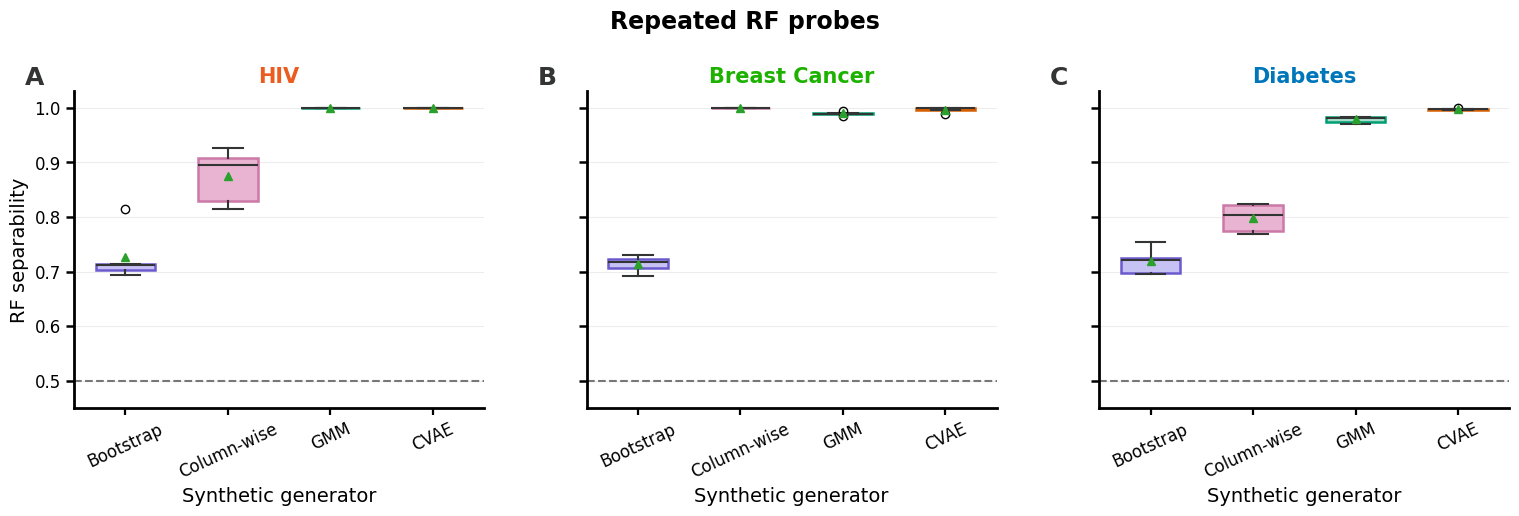

In [165]:
def plot_auc_boxplot_helper(auc_runs):
    """Optional diagnostic: repeated RF separability boxplots by dataset."""
    fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.8), sharey=True, constrained_layout=False)
    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        sub = auc_runs[auc_runs["dataset"] == ds]
        data = [sub[sub["method"] == method]["separability_auc"].to_numpy() for method in METHOD_ORDER]
        bp = ax.boxplot(data, tick_labels=METHOD_ORDER, patch_artist=True, showmeans=True, widths=0.58)
        for patch, method in zip(bp["boxes"], METHOD_ORDER):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.8)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.5)
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.5)
        ax.set_ylim(0.45, 1.03)
        ax.set_title(ds, color=DATASET_COLORS[ds], weight="bold")
        ax.set_xlabel("Synthetic generator")
        ax.tick_params(axis="x", rotation=25, width=1.6, length=5)
        clean_axis(ax, grid_axis="y")
        ax.spines["left"].set_linewidth(2.0)
        ax.spines["bottom"].set_linewidth(2.0)
        add_panel_label(ax, panel)
    axes[0].set_ylabel("RF separability")

    fig.suptitle("Repeated RF probes", y=0.99, fontsize=17, weight="bold")
    fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.16, wspace=0.25)
    plt.show()


# Optional diagnostic:
plot_auc_boxplot_helper(auc_runs)


## Figure 3 - metric summary and violin panels

This section renders the manuscript Figure 3 outputs: conventional synthetic-data quality metrics and the basic distribution-fidelity summaries that support them.

- Table: discriminator performance, TSTR utility, utility gap, mean feature KLD, and nearest-neighbor realism summaries across datasets and synthetic generators.
- Panel A: real-vs-synthetic discriminator AUC by synthetic generator.
- Panel B: TSTR F1 by synthetic generator.
- Panel C: absolute `TRTR - TSTR` by synthetic generator, where smaller is better.

Violin distributions show repeated runs where available, with mean and SD overlaid. Feature-level marginal/KLD plots are treated as supplementary diagnostics so Figure 4 can focus on multivariate biological structure.


[metric table] HIV - Bootstrap
[metric table] HIV - Column-wise
[metric table] HIV - GMM
[metric table] HIV - CVAE
Epoch    1 | train loss=66.5142 recon=66.4437 kl=0.1410 | val loss=78.9503 recon=78.8778 kl=0.1451
Epoch   10 | train loss=99.0797 recon=98.6632 kl=0.8329 | val loss=77.2854 recon=76.9990 kl=0.5728
[metric table] Breast Cancer - Bootstrap
[metric table] Breast Cancer - Column-wise
[metric table] Breast Cancer - GMM
[metric table] Breast Cancer - CVAE
Epoch    1 | train loss=28.5698 recon=28.5130 kl=0.1136 | val loss=26.3495 recon=26.2723 kl=0.1543
Epoch   10 | train loss=14.7790 recon=12.6115 kl=4.3351 | val loss=12.9616 recon=10.7876 kl=4.3480
[metric table] Diabetes - Bootstrap
[metric table] Diabetes - Column-wise
[metric table] Diabetes - GMM
[metric table] Diabetes - CVAE
Epoch    1 | train loss=8.1392 recon=8.1031 kl=0.0723 | val loss=9.7181 recon=9.6747 kl=0.0869
Epoch   10 | train loss=5.2657 recon=3.7684 kl=2.9946 | val loss=5.5699 recon=3.5904 kl=3.9590


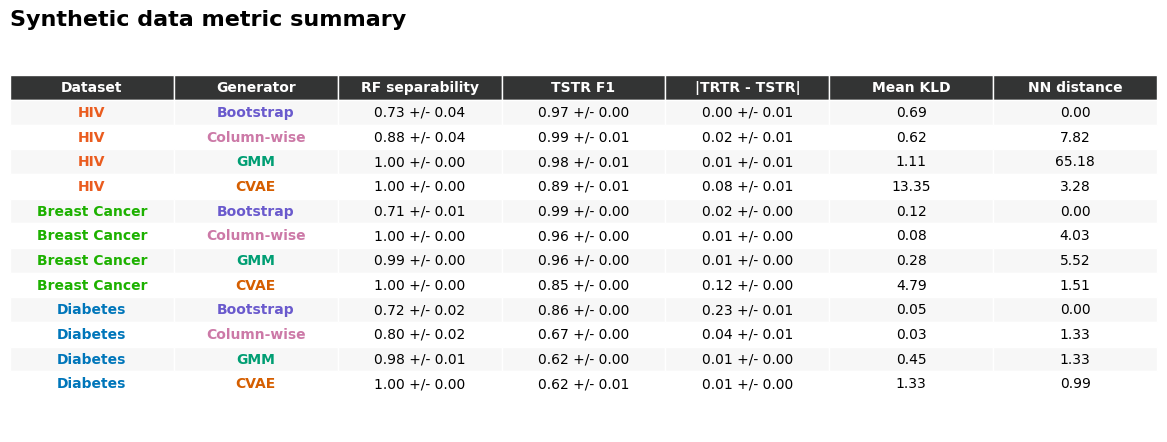

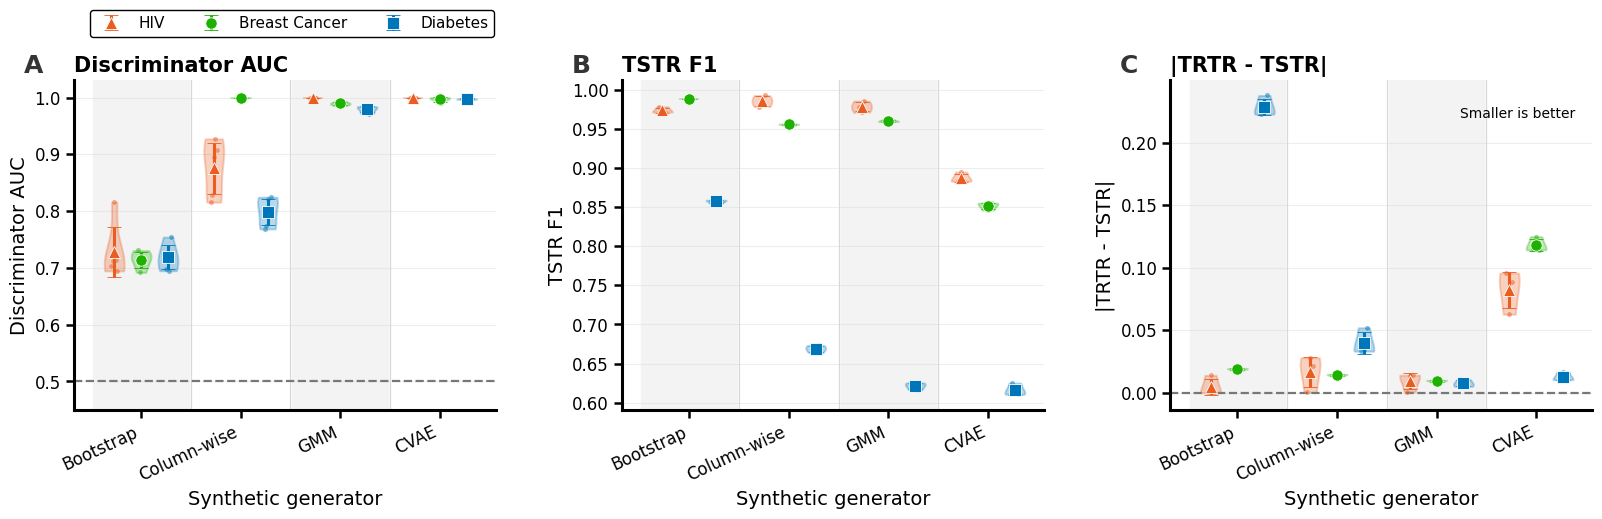

In [166]:
def mean_kld_by_feature(X_real, X_syn, bins=30):
    X_real = np.asarray(X_real, dtype=float)
    X_syn = np.asarray(X_syn, dtype=float)
    vals = []
    for j in range(X_real.shape[1]):
        lo = float(min(np.nanmin(X_real[:, j]), np.nanmin(X_syn[:, j])))
        hi = float(max(np.nanmax(X_real[:, j]), np.nanmax(X_syn[:, j])))
        if not np.isfinite(lo + hi) or hi <= lo:
            vals.append(0.0)
            continue
        edges = np.linspace(lo, hi, bins + 1)
        p, _ = np.histogram(X_real[:, j], bins=edges, density=True)
        q, _ = np.histogram(X_syn[:, j], bins=edges, density=True)
        p = p + 1e-10
        q = q + 1e-10
        vals.append(float(entropy(p / p.sum(), q / q.sum())))
    return np.asarray(vals, dtype=float)


def nn_distance_mean(X_real, X_syn):
    Xr, Xs = standardize_pair(X_real, X_syn)
    nn = NearestNeighbors(n_neighbors=1).fit(Xr)
    dists, _ = nn.kneighbors(Xs)
    return float(np.mean(dists))


def tstr_values(X_real, y_real, X_syn, y_syn, seed=SEED, repeats=TSTR_REPEATS):
    Xr, Xs = standardize_pair(X_real, X_syn)
    y_real = np.asarray(y_real, dtype=int)
    y_syn = np.asarray(y_syn, dtype=int)
    n_splits = max(2, min(5, int((y_real == 0).sum()), int((y_real == 1).sum())))
    out = []
    trtr = []
    for r in range(repeats):
        run_seed = seed + r * 1009
        clf = RandomForestClassifier(n_estimators=300, random_state=run_seed, class_weight="balanced", n_jobs=-1)
        clf.fit(Xs, y_syn)
        out.append(float(f1_score(y_real, clf.predict(Xr), zero_division=0)))
        fold_scores = []
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run_seed)
        for train_idx, test_idx in cv.split(Xr, y_real):
            rf = RandomForestClassifier(n_estimators=300, random_state=run_seed, class_weight="balanced", n_jobs=-1)
            rf.fit(Xr[train_idx], y_real[train_idx])
            fold_scores.append(float(f1_score(y_real[test_idx], rf.predict(Xr[test_idx]), zero_division=0)))
        trtr.append(float(np.mean(fold_scores)))
    return np.asarray(out), np.asarray(trtr)


def build_metric_table(datasets, auc_runs, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        y_real = np.asarray(data["y"], dtype=int)
        for method in METHOD_ORDER:
            print(f"[metric table] {ds} - {method}")
            X_syn, y_syn = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            tstr, trtr = tstr_values(X_real, y_real, X_syn, y_syn, seed=seed)
            gap = np.abs(trtr - tstr)
            auc_vals = auc_runs[(auc_runs["dataset"] == ds) & (auc_runs["method"] == method)]["separability_auc"].to_numpy()
            klds = mean_kld_by_feature(X_real, X_syn)
            rows.append({
                "dataset": ds,
                "method": method,
                "rf_auc_mean": float(np.mean(auc_vals)),
                "rf_auc_sd": float(np.std(auc_vals)),
                "rf_auc_values": auc_vals.tolist(),
                "tstr_f1_mean": float(np.mean(tstr)),
                "tstr_f1_sd": float(np.std(tstr)),
                "tstr_f1_values": tstr.tolist(),
                "utility_gap_abs_mean": float(np.mean(gap)),
                "utility_gap_abs_sd": float(np.std(gap)),
                "utility_gap_abs_values": gap.tolist(),
                "mean_feature_kld": float(np.mean(klds)),
                "nn_distance_mean": nn_distance_mean(X_real, X_syn),
            })
    return pd.DataFrame(rows)


def format_mean_sd(mean, sd):
    return f"{mean:.2f} +/- {sd:.2f}"


def plot_metric_table_image(metric_table):
    table_df = metric_table.copy()
    table_df["RF separability"] = [format_mean_sd(m, s) for m, s in zip(table_df["rf_auc_mean"], table_df["rf_auc_sd"])]
    table_df["TSTR F1"] = [format_mean_sd(m, s) for m, s in zip(table_df["tstr_f1_mean"], table_df["tstr_f1_sd"])]
    table_df["|TRTR - TSTR|"] = [format_mean_sd(m, s) for m, s in zip(table_df["utility_gap_abs_mean"], table_df["utility_gap_abs_sd"])]
    table_df["Mean KLD"] = table_df["mean_feature_kld"].map(lambda v: f"{v:.2f}")
    table_df["NN distance"] = table_df["nn_distance_mean"].map(lambda v: f"{v:.2f}")
    table_df = table_df[["dataset", "method", "RF separability", "TSTR F1", "|TRTR - TSTR|", "Mean KLD", "NN distance"]]
    table_df.columns = ["Dataset", "Generator", "RF separability", "TSTR F1", "|TRTR - TSTR|", "Mean KLD", "NN distance"]

    fig, ax = plt.subplots(figsize=(14.8, 5.1))
    ax.axis("off")
    tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns, loc="center", cellLoc="center", colLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10.0)
    tbl.scale(1.0, 1.48)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("white")
        if r == 0:
            cell.set_facecolor(NEUTRAL)
            cell.set_text_props(color="white", weight="bold")
        else:
            ds = table_df.iloc[r-1]["Dataset"]
            cell.set_facecolor("#F7F7F7" if r % 2 else "#FFFFFF")
            if c == 0:
                cell.set_text_props(color=DATASET_COLORS.get(ds, NEUTRAL), weight="bold")
            if c == 1:
                method = table_df.iloc[r-1]["Generator"]
                cell.set_text_props(color=METHOD_COLORS.get(method, NEUTRAL), weight="bold")
    ax.set_title("Synthetic data metric summary", loc="left", fontsize=16, weight="bold", pad=10)
    plt.show()


def _metric_values(row, value_col, mean_col):
    vals = row.get(value_col, None)
    if isinstance(vals, (list, tuple, np.ndarray)) and len(vals) > 0:
        return np.asarray(vals, dtype=float)
    return np.asarray([float(row[mean_col])], dtype=float)


def _draw_grouped_violin_panel(ax, metric_table, value_col, mean_col, sd_col, ylabel, panel, ylim=None):
    x = np.arange(len(METHOD_ORDER))
    offsets = np.linspace(-0.27, 0.27, len(DATASET_ORDER))
    width = 0.20
    legend_handles = []

    for i, method in enumerate(METHOD_ORDER):
        if i % 2 == 0:
            ax.axvspan(i - 0.48, i + 0.48, color="#F3F3F3", zorder=0)
        if i > 0:
            ax.axvline(i - 0.5, color="#D8D8D8", linewidth=0.9, zorder=0)

    for offset, ds in zip(offsets, DATASET_ORDER):
        sub = metric_table[metric_table["dataset"] == ds].set_index("method").reindex(METHOD_ORDER)
        positions = x + offset
        values = [_metric_values(row, value_col, mean_col) for _, row in sub.iterrows()]
        violins = ax.violinplot(values, positions=positions, widths=width, showmeans=False, showmedians=False, showextrema=False)
        for body in violins["bodies"]:
            body.set_facecolor(DATASET_COLORS[ds])
            body.set_edgecolor(DATASET_COLORS[ds])
            body.set_alpha(0.28)
            body.set_linewidth(1.4)
            body.set_zorder(2)
        for pos, vals in zip(positions, values):
            jitter = np.linspace(-0.030, 0.030, len(vals)) if len(vals) > 1 else np.array([0.0])
            ax.scatter(np.full(len(vals), pos) + jitter, vals, s=14, color=DATASET_COLORS[ds], alpha=0.50,
                       edgecolors="white", linewidths=0.25, zorder=3)
        means = sub[mean_col].to_numpy(dtype=float)
        sds = sub[sd_col].to_numpy(dtype=float)
        handle = ax.errorbar(positions, means, yerr=sds, color=DATASET_COLORS[ds], marker=DATASET_MARKERS[ds],
                             linestyle="none", markersize=8.2, elinewidth=2.2, capsize=5.0, capthick=2.0,
                             markeredgecolor="white", markeredgewidth=0.6, label=ds, zorder=4)
        legend_handles.append(handle)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=25, ha="right")
    ax.set_xlabel("Synthetic generator")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    if mean_col == "rf_auc_mean":
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.6)
    if mean_col == "utility_gap_abs_mean":
        ax.axhline(0, color="#777777", linestyle="--", linewidth=1.6)
        ax.text(0.96, 0.92, "Smaller is better", ha="right", va="top", transform=ax.transAxes, fontsize=10.0)
    ax.set_title(ylabel, loc="left", weight="bold")
    clean_axis(ax, grid_axis="y")
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(2.2)
    ax.tick_params(width=1.8, length=6)
    add_panel_label(ax, panel)
    return legend_handles

def plot_figure3_metric_panels(metric_table):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4), constrained_layout=False)
    panel_specs = [
        ("rf_auc_values", "rf_auc_mean", "rf_auc_sd", "Discriminator AUC", "A", (0.45, 1.03)),
        ("tstr_f1_values", "tstr_f1_mean", "tstr_f1_sd", "TSTR F1", "B", None),
        ("utility_gap_abs_values", "utility_gap_abs_mean", "utility_gap_abs_sd", "|TRTR - TSTR|", "C", None),
    ]
    legend_handles = None
    for ax, spec in zip(axes, panel_specs):
        handles = _draw_grouped_violin_panel(ax, metric_table, *spec)
        if legend_handles is None:
            legend_handles = handles
    fig.legend(legend_handles, DATASET_ORDER, loc="upper left", bbox_to_anchor=(0.075, 0.985), ncol=3,
               frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
    fig.subplots_adjust(left=0.07, right=0.99, top=0.84, bottom=0.23, wspace=0.30)
    plt.show()

metric_table = build_metric_table(datasets, auc_runs)
plot_metric_table_image(metric_table)
plot_figure3_metric_panels(metric_table)


## Figure 4 - preservation of multivariate biological structure

This figure treats the real correlation heatmap as the target/original structure, then reports how far each synthetic method's correlation matrix deviates from that target using the Frobenius norm:

`||C_real - C_synthetic||_F`

Panels A-C show the real HIV, breast cancer, and diabetes correlation heatmaps. Panel D summarizes synthetic deviation from the real matrix for each dataset and method. Lower discrepancy means the synthetic method better preserves the real feature-correlation structure.


In [ ]:
def feature_group(name):
    lower = str(name).lower()
    if "igg" in lower and "saliva" in lower:
        return "saliva IgG"
    if "iga" in lower:
        return "saliva IgA"
    if "igg" in lower and ("blood" in lower or "serum" in lower):
        return "serum IgG"
    if "ifng" in lower or "il2" in lower or "dual" in lower:
        return "cytokines"
    if "ace2" in lower or "neut" in lower or "neutral" in lower or "rbd" in lower:
        return "neutralization/ACE2"
    return "other"


FEATURE_GROUP_COLORS = {
    "serum IgG": "#8C564B",
    "saliva IgG": "#D62728",
    "saliva IgA": "#4C78A8",
    "cytokines": "#F2B447",
    "neutralization/ACE2": "#8DBF56",
    "other": "#9E9E9E",
}

PASTEL_CORR_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "pastel_corr", ["#8FB7D6", "#F7F7F2", "#D9A067"], N=256
)
ABS_CORR_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "pastel_abs_corr", ["#FBFAF7", "#CFE7DF", "#71B6A4", "#2F7F75"], N=256
)


def target_rf_importance(X, y, seed=SEED):
    Xs = StandardScaler().fit_transform(np.asarray(X, dtype=float))
    rf = RandomForestClassifier(n_estimators=800, random_state=seed, class_weight="balanced", n_jobs=-1)
    rf.fit(Xs, np.asarray(y, dtype=int))
    return rf.feature_importances_


def corr_matrix(X):
    C = np.corrcoef(np.asarray(X, dtype=float), rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(C, 1.0)
    return C


def upper_triangle_values(C):
    idx = np.triu_indices_from(C, k=1)
    return C[idx]


def corr_preservation_summary(real_corr, syn_corr):
    x = upper_triangle_values(real_corr)
    y = upper_triangle_values(syn_corr)
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 2 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    mae = float(np.mean(np.abs(x - y)))
    return x, y, r, mae


def color_feature_ticklabels(ax, top_features):
    top_features = set(top_features)
    for label in ax.get_yticklabels():
        txt = label.get_text()
        if txt in top_features:
            label.set_color(FEATURE_GROUP_COLORS.get(feature_group(txt), NEUTRAL))
            label.set_fontweight("bold")
            label.set_alpha(1.0)
        else:
            label.set_color("#777777")
            label.set_alpha(0.38)


def short_feature_name(name, max_len=18):
    name = str(name).replace("_", " ")
    return name if len(name) <= max_len else name[:max_len - 1] + "..."


def draw_corr_heatmap(ax, fig, matrix, ordered_features, title, show_y=True, top_features=None):
    im = ax.imshow(matrix, aspect="auto", cmap=PASTEL_CORR_CMAP, vmin=-1, vmax=1)
    ax.set_title(title, loc="left", weight="bold", fontsize=12.8)
    ax.set_xticks([])
    if show_y:
        ax.set_yticks(np.arange(len(ordered_features)))
        ax.set_yticklabels(ordered_features, fontsize=5.8)
        color_feature_ticklabels(ax, top_features or [])
    else:
        ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("#444444")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
    cbar.ax.tick_params(labelsize=8.5, width=1.2, length=3)
    cbar.outline.set_linewidth(1.0)
    return im


def draw_abs_corr_heatmap(ax, fig, matrix, ordered_features, title, show_y=False):
    vmax = max(0.15, float(np.nanpercentile(matrix, 98)))
    im = ax.imshow(matrix, aspect="auto", cmap=ABS_CORR_CMAP, vmin=0, vmax=min(vmax, 1.0))
    ax.set_title(title, loc="left", weight="bold", fontsize=12.8)
    ax.set_xticks([])
    if show_y:
        ax.set_yticks(np.arange(len(ordered_features)))
        ax.set_yticklabels(ordered_features, fontsize=5.8)
    else:
        ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("#444444")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.015)
    cbar.ax.tick_params(labelsize=8.5, width=1.2, length=3)
    cbar.outline.set_linewidth(1.0)
    cbar.set_label("absolute difference", fontsize=9.0)
    return im


def plot_marginal_violin_strip(ax, X_real, X_syn, feature_names, order_idx, representative_method, top_n=10):
    top_idx = list(order_idx[:min(top_n, len(order_idx))])
    Xr_z, Xs_z = standardize_pair(X_real, X_syn)
    positions = np.arange(len(top_idx), dtype=float)
    real_color = "#D5D7DA"
    syn_color = METHOD_COLORS.get(representative_method, "#009E73")

    for pos, feat_idx in zip(positions, top_idx):
        group_color = FEATURE_GROUP_COLORS.get(feature_group(feature_names[feat_idx]), "#9E9E9E")
        vp_real = ax.violinplot([Xr_z[:, feat_idx]], positions=[pos - 0.17], widths=0.28,
                                showmeans=False, showmedians=True, showextrema=False)
        vp_syn = ax.violinplot([Xs_z[:, feat_idx]], positions=[pos + 0.17], widths=0.28,
                               showmeans=False, showmedians=True, showextrema=False)
        for body in vp_real["bodies"]:
            body.set_facecolor(real_color)
            body.set_edgecolor("#5E5E5E")
            body.set_alpha(0.92)
            body.set_linewidth(1.0)
        for body in vp_syn["bodies"]:
            body.set_facecolor(syn_color)
            body.set_edgecolor(group_color)
            body.set_alpha(0.72)
            body.set_linewidth(1.2)
        for key in ["cmedians"]:
            vp_real[key].set_color("#333333")
            vp_real[key].set_linewidth(1.2)
            vp_syn[key].set_color("#333333")
            vp_syn[key].set_linewidth(1.2)

    labels = [short_feature_name(feature_names[i], 16) for i in top_idx]
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8.2)
    for tick, feat_idx in zip(ax.get_xticklabels(), top_idx):
        tick.set_color(FEATURE_GROUP_COLORS.get(feature_group(feature_names[feat_idx]), NEUTRAL))
        tick.set_fontweight("bold")
    ax.axhline(0, color="#777777", linewidth=1.0, alpha=0.55)
    ax.set_ylabel("z-scored feature value")
    ax.set_title("Marginal feature distributions", loc="left", weight="bold")
    clean_axis(ax, grid_axis="y")
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(width=1.6, length=5)

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=real_color, edgecolor="#5E5E5E", label="Real"),
        Rectangle((0, 0), 1, 1, facecolor=syn_color, edgecolor="#333333", alpha=0.72, label=representative_method),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True, facecolor="white", edgecolor="black",
              framealpha=0.96, fontsize=9.0, borderpad=0.35, handlelength=1.2)


def correlation_frobenius_discrepancy(real_corr, syn_corr):
    return float(np.linalg.norm(np.asarray(real_corr, dtype=float) - np.asarray(syn_corr, dtype=float), ord="fro"))


def ordered_real_correlation(dataset, data, seed=SEED):
    X_real = np.asarray(data["X"], dtype=np.float32)
    y_real = np.asarray(data["y"], dtype=int)
    feature_names = list(data.get("feature_names", [f"F{i+1}" for i in range(X_real.shape[1])]))
    importances = target_rf_importance(X_real, y_real, seed=seed)
    order_idx = np.argsort(importances)[::-1]
    ordered_features = [feature_names[i] for i in order_idx]
    Xr_scaled, _ = standardize_pair(X_real, X_real)
    real_corr = corr_matrix(Xr_scaled)[:, order_idx][order_idx, :]
    return real_corr, ordered_features, order_idx


def compute_figure4_frobenius_summary(datasets, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        real_corr = corr_matrix(X_real)
        for method in METHOD_ORDER:
            print(f"[figure4] {ds} - {method}")
            X_syn, _ = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            syn_corr = corr_matrix(X_syn)
            rows.append({
                "dataset": ds,
                "method": method,
                "frobenius_corr_discrepancy": correlation_frobenius_discrepancy(real_corr, syn_corr),
            })
    return pd.DataFrame(rows)


def draw_real_corr_heatmap(ax, fig, dataset, data, panel):
    real_corr, ordered_features, _ = ordered_real_correlation(dataset, data)
    im = ax.imshow(real_corr, aspect="auto", cmap=PASTEL_CORR_CMAP, vmin=-1, vmax=1)
    ax.set_title(dataset, color=DATASET_COLORS[dataset], weight="semibold", pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.04, 0.05, f"p={real_corr.shape[0]}", transform=ax.transAxes,
        ha="left", va="bottom", color=DATASET_COLORS[dataset], fontsize=8.7, weight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, pad=2.5),
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)
    add_panel_label(ax, panel)
    return im


def draw_frobenius_discrepancy(ax, frobenius_summary, panel):
    table = (
        frobenius_summary
        .pivot(index="dataset", columns="method", values="frobenius_corr_discrepancy")
        .reindex(DATASET_ORDER)[METHOD_ORDER]
    )
    x = np.arange(len(DATASET_ORDER))
    offsets = np.linspace(-0.27, 0.27, len(METHOD_ORDER))
    width = 0.15
    max_y = float(np.nanmax(table.to_numpy(dtype=float)))

    for offset, method in zip(offsets, METHOD_ORDER):
        vals = table[method].to_numpy(dtype=float)
        ax.bar(
            x + offset, vals, width=width, color=METHOD_PASTELS[method], edgecolor=METHOD_COLORS[method],
            linewidth=1.25, label=method, zorder=2,
        )
        ax.scatter(x + offset, vals, s=28, color=METHOD_COLORS[method], edgecolor="white", linewidth=0.7, zorder=3)
        for xi, val in zip(x + offset, vals):
            ax.text(xi, val + max_y * 0.025, f"{val:.1f}", ha="center", va="bottom", fontsize=7.4, color="#333333")

    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER, rotation=15, ha="right")
    ax.set_ylabel(r"$||C_{real} - C_{synthetic}||_F$")
    ax.set_title("Synthetic discrepancy from real", weight="semibold", pad=8)
    ax.set_ylim(0, max_y * 1.18)
    clean_axis(ax, grid_axis="y")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8.5)
    add_panel_label(ax, panel)
    return table


def plot_figure4_structure_panel(datasets, frobenius_summary=None, seed=SEED, cvae_epochs=CVAE_EPOCHS):
    if frobenius_summary is None:
        frobenius_summary = compute_figure4_frobenius_summary(datasets, seed=seed, cvae_epochs=cvae_epochs)

    fig = plt.figure(figsize=(14.4, 7.6), constrained_layout=False)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.95], hspace=0.34, wspace=0.24)
    heatmap_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    ax_summary = fig.add_subplot(gs[1, :])

    heatmap_images = []
    for ax, ds, panel in zip(heatmap_axes, DATASET_ORDER, ["A", "B", "C"]):
        heatmap_images.append(draw_real_corr_heatmap(ax, fig, ds, datasets[ds], panel))

    cbar = fig.colorbar(heatmap_images[0], ax=heatmap_axes, fraction=0.032, pad=0.018)
    cbar.set_label("Real feature correlation", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    draw_frobenius_discrepancy(ax_summary, frobenius_summary, "D")
    fig.suptitle("Figure 4. Real feature-correlation structure and synthetic discrepancy", y=0.975, fontsize=15.5, weight="semibold")
    fig.text(
        0.5, 0.025,
        r"Panels A-C show the real correlation matrix for each dataset. Panel D reports $||C_{real} - C_{synthetic}||_F$; lower values indicate better preservation of the real correlation structure.",
        ha="center", va="bottom", fontsize=9.5, color="#444444",
    )
    fig.subplots_adjust(left=0.07, right=0.88, top=0.90, bottom=0.13)
    return fig


figure4_frobenius_summary = compute_figure4_frobenius_summary(datasets)
fig4_structure = plot_figure4_structure_panel(datasets, figure4_frobenius_summary)
plt.show()


In [168]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = ranked * n / np.arange(1, n + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return out


def feature_shift_table(dataset, data, method="GMM", seed=SEED, cvae_epochs=CVAE_EPOCHS):
    X_real = np.asarray(data["X"], dtype=float)
    feature_names = list(data.get("feature_names", [f"F{i+1}" for i in range(X_real.shape[1])]))
    X_syn, _ = sample_synthetic(dataset, data, method, seed=seed, cvae_epochs=cvae_epochs)
    X_syn = np.asarray(X_syn, dtype=float)
    pvals = []
    rows = []
    for j, feature in enumerate(feature_names):
        stat = ttest_ind(X_real[:, j], X_syn[:, j], equal_var=False, nan_policy="omit")
        pvals.append(float(stat.pvalue) if np.isfinite(stat.pvalue) else 1.0)
        rows.append({
            "dataset": dataset,
            "method": method,
            "feature": feature,
            "real_mean": float(np.nanmean(X_real[:, j])),
            "syn_mean": float(np.nanmean(X_syn[:, j])),
            "mean_diff": float(np.nanmean(X_real[:, j]) - np.nanmean(X_syn[:, j])),
        })
    out = pd.DataFrame(rows)
    out["p_value"] = pvals
    out["p_adj"] = benjamini_hochberg(pvals)
    out["neglog10_padj"] = -np.log10(np.maximum(out["p_adj"], 1e-300))
    out["significant"] = out["p_adj"] < 0.05
    out["feature_group"] = [feature_group(feature) for feature in out["feature"]]
    return out.sort_values("p_adj")


def plot_feature_shift_volcano(shift_df):
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    for group, group_df in shift_df.groupby("feature_group", sort=False):
        ax.scatter(group_df["mean_diff"], group_df["neglog10_padj"],
                   s=np.where(group_df["significant"], 48, 28),
                   color=FEATURE_GROUP_COLORS.get(group, "#9E9E9E"),
                   alpha=np.where(group_df["significant"], 0.88, 0.42),
                   edgecolors="white", linewidths=0.35, label=group)
    ax.axhline(-np.log10(0.05), color="#555555", linestyle="--", linewidth=1.4)
    ax.axvline(0, color="#777777", linestyle=":", linewidth=1.2)
    ax.set_xlabel("Mean difference (real - synthetic)")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(f"Distribution-shift companion ({shift_df['method'].iloc[0]})", loc="left", weight="bold")
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fontsize=8.5,
              title="Feature group", title_fontsize=9.0)
    clean_axis(ax, grid_axis="y")
    plt.show()


# Optional companion diagnostic, not part of the main Figure 4 layout.
# hiv_shift = feature_shift_table("HIV", datasets["HIV"], method="GMM")
# display(hiv_shift.head(15))
# plot_feature_shift_volcano(hiv_shift)


## Figure 5 - discriminator AUC versus noise

Figure 5 shows discriminator AUC as a function of controlled noise.

Noise is added to each synthetic feature as `X_noisy[:, j] = X_syn[:, j] + Normal(0, 1) * sigma * SD(X_real[:, j])`, where `SD(X_real[:, j])` is computed from the stratified real-data subsample used for the noise sweep. Thus `sigma = 0` is the unperturbed synthetic-data baseline for that generator, not zero discriminator signal.

- X-axis: noise factor.
- Y-axis: discriminator AUC / RF separability.
- Each panel represents one dataset.
- Lines vary by synthetic generation method.
- Colors follow the method palette used elsewhere in the notebook.

Supplementary figure: F1 score versus noise should use the same layout as Figure 5.


[noise] training CVAE for HIV
[noise] HIV Bootstrap sigma=0.0
[noise] HIV Bootstrap sigma=0.2
[noise] HIV Bootstrap sigma=0.5
[noise] HIV Bootstrap sigma=1.0
[noise] HIV Column-wise sigma=0.0
[noise] HIV Column-wise sigma=0.2
[noise] HIV Column-wise sigma=0.5
[noise] HIV Column-wise sigma=1.0
[noise] HIV GMM sigma=0.0
[noise] HIV GMM sigma=0.2
[noise] HIV GMM sigma=0.5
[noise] HIV GMM sigma=1.0
[noise] HIV CVAE sigma=0.0
[noise] HIV CVAE sigma=0.2
[noise] HIV CVAE sigma=0.5
[noise] HIV CVAE sigma=1.0
[noise] training CVAE for Breast Cancer
[noise] Breast Cancer Bootstrap sigma=0.0
[noise] Breast Cancer Bootstrap sigma=0.2
[noise] Breast Cancer Bootstrap sigma=0.5
[noise] Breast Cancer Bootstrap sigma=1.0
[noise] Breast Cancer Column-wise sigma=0.0
[noise] Breast Cancer Column-wise sigma=0.2
[noise] Breast Cancer Column-wise sigma=0.5
[noise] Breast Cancer Column-wise sigma=1.0
[noise] Breast Cancer GMM sigma=0.0
[noise] Breast Cancer GMM sigma=0.2
[noise] Breast Cancer GMM sigma=0.5
[n

,dataset,method,sigma,sep_mean,sep_sd,sep_values
0,HIV,Bootstrap,0.0,0.733594,0.040625,"[0.77421875, 0.69296875]"
1,HIV,Bootstrap,0.2,0.541797,0.010547,"[0.55234375, 0.53125]"
2,HIV,Bootstrap,0.5,0.853125,0.070312,"[0.9234375, 0.7828125]"
3,HIV,Bootstrap,1.0,0.951562,0.017188,"[0.96875, 0.934375]"
4,HIV,Column-wise,0.0,0.679688,0.035156,"[0.71484375, 0.64453125]"


c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,dataset,method,sigma,auc_at_sigma0,auc_at_sigma,delta_auc,p_value_vs_sigma0,q_value_bh
0,Breast Cancer,Bootstrap,0.2,0.689139,0.616638,-0.072501,0.088193,0.162460
1,Breast Cancer,Bootstrap,0.5,0.689139,0.859938,0.170800,0.039798,0.116076
2,Breast Cancer,Bootstrap,1.0,0.689139,0.979796,0.290657,0.019656,0.097032
3,Breast Cancer,CVAE,0.2,0.996424,0.990273,-0.006151,0.270913,0.351183
4,Breast Cancer,CVAE,0.5,0.996424,0.962409,-0.034016,0.078703,0.158242


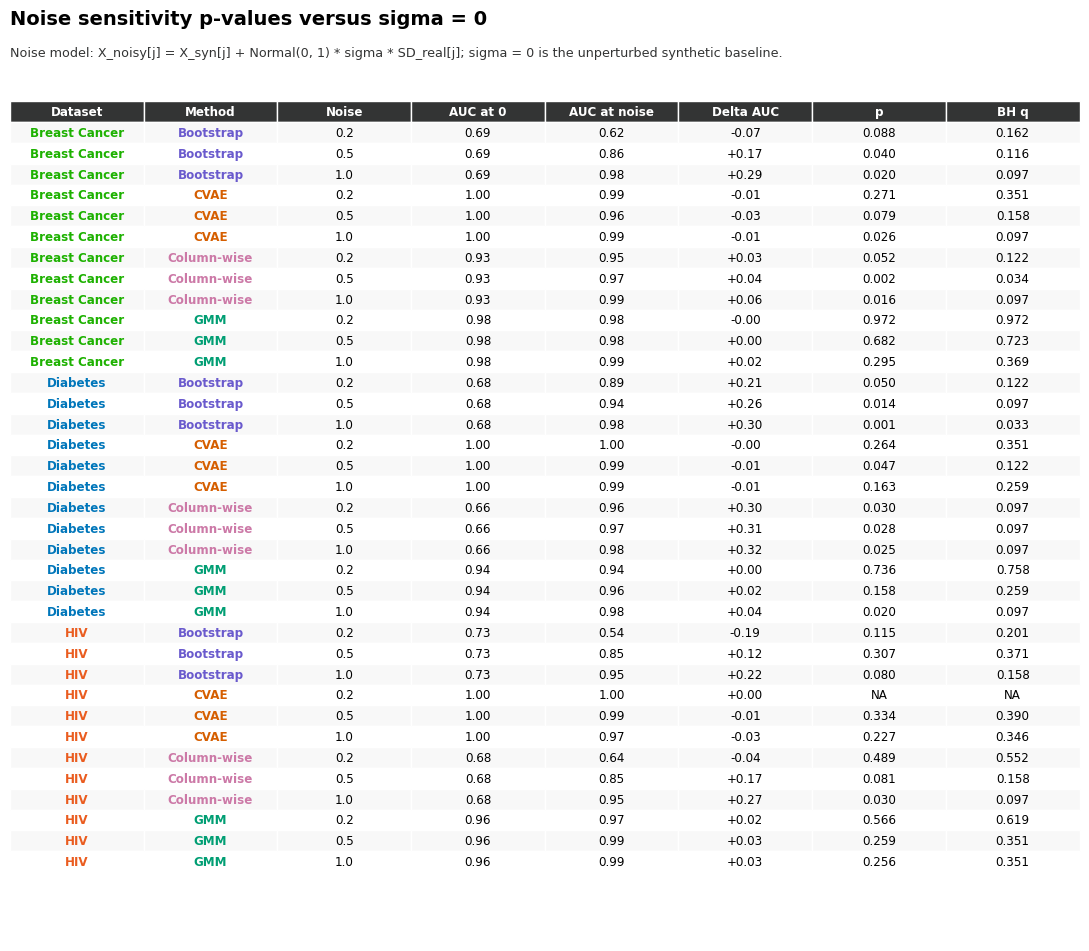

In [169]:
def stratified_subsample(X, y, n0, n1, seed=SEED):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    take0 = rng.choice(idx0, size=max(1, min(n0, len(idx0))), replace=False)
    take1 = rng.choice(idx1, size=max(1, min(n1, len(idx1))), replace=False)
    idx = np.r_[take0, take1]
    rng.shuffle(idx)
    return X[idx], y[idx]


def compute_noise_sensitivity(datasets, seed=SEED, repeats=NOISE_REPEATS, sigmas=PROBE_SIGMAS, frac=NOISE_FRAC, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X = np.asarray(data["X"], dtype=np.float32)
        y = np.asarray(data["y"], dtype=int)
        n0 = max(2, int((y == 0).sum() * frac))
        n1 = max(2, int((y == 1).sum() * frac))
        X_sub, y_sub = stratified_subsample(X, y, n0, n1, seed=seed)
        stds = X_sub.std(axis=0)
        stds = np.where(stds == 0, 1.0, stds)
        feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]
        print(f"[noise] training CVAE for {ds}")
        state = train_cvae(X_sub, y_sub, cfg=Config(seed=seed, epochs=cvae_epochs, batch_size=32), verbose=False)
        generators = {
            "Bootstrap": lambda s: sample_bootstrap(X_sub, y_sub, n0, n1, seed=s),
            "Column-wise": lambda s: sample_columnwise(X_sub, y_sub, n0, n1, seed=s),
            "GMM": lambda s: sample_gmm(X_sub, y_sub, n0, n1, seed=s),
            "CVAE": lambda s: sample_trained_cvae(state, n0, n1, seed=s),
        }
        for method, gen in generators.items():
            for sigma in sigmas:
                vals = []
                for r in range(repeats):
                    rep_seed = seed + r
                    X_syn, _ = gen(rep_seed)
                    X_syn = np.asarray(X_syn, dtype=np.float64)
                    if sigma > 0:
                        rng = np.random.default_rng(rep_seed + 500)
                        X_syn = X_syn + rng.standard_normal(X_syn.shape) * stds * sigma
                    real_df = pd.DataFrame(X_sub, columns=feat_cols)
                    real_df["target"] = 1
                    syn_df = pd.DataFrame(X_syn, columns=feat_cols)
                    syn_df["target"] = 0
                    combined = pd.concat([real_df, syn_df], ignore_index=True)
                    avg, _, _ = RFWrapper.from_combined(combined)
                    vals.append(max(float(avg), 1.0 - float(avg)))
                rows.append({"dataset": ds, "method": method, "sigma": sigma,
                             "sep_mean": float(np.mean(vals)), "sep_sd": float(np.std(vals)),
                             "sep_values": [float(v) for v in vals]})
                print(f"[noise] {ds} {method} sigma={sigma}")
    return pd.DataFrame(rows)


def build_noise_pvalue_table(noise_df):
    """Compare each noise level with sigma=0 within dataset/method."""
    rows = []
    for (dataset, method), sub in noise_df.groupby(["dataset", "method"]):
        base_rows = sub[sub["sigma"] == 0]
        if base_rows.empty:
            continue
        base_vals = np.asarray(base_rows.iloc[0].get("sep_values", []), dtype=float)
        for _, row in sub[sub["sigma"] != 0].iterrows():
            vals = np.asarray(row.get("sep_values", []), dtype=float)
            if len(base_vals) >= 2 and len(vals) >= 2:
                p_value = float(ttest_ind(base_vals, vals, equal_var=False, nan_policy="omit").pvalue)
            else:
                p_value = np.nan
            rows.append({
                "dataset": dataset,
                "method": method,
                "sigma": float(row["sigma"]),
                "auc_at_sigma0": float(np.mean(base_vals)) if len(base_vals) else np.nan,
                "auc_at_sigma": float(np.mean(vals)) if len(vals) else np.nan,
                "delta_auc": float(np.mean(vals) - np.mean(base_vals)) if len(base_vals) and len(vals) else np.nan,
                "p_value_vs_sigma0": p_value,
            })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    p = out["p_value_vs_sigma0"].to_numpy(dtype=float)
    valid = np.isfinite(p)
    q = np.full_like(p, np.nan, dtype=float)
    if valid.any():
        order = np.argsort(p[valid])
        ranked = p[valid][order]
        n = len(ranked)
        adj = ranked * n / np.arange(1, n + 1)
        adj = np.minimum.accumulate(adj[::-1])[::-1]
        valid_idx = np.where(valid)[0]
        q[valid_idx[order]] = np.clip(adj, 0, 1)
    out["q_value_bh"] = q
    return out.sort_values(["dataset", "method", "sigma"])


def plot_noise_pvalue_table(noise_stats):
    if noise_stats.empty:
        display(Markdown("No noise p-value rows available."))
        return
    show = noise_stats.copy()
    show["AUC sigma=0"] = show["auc_at_sigma0"].map(lambda v: f"{v:.2f}")
    show["AUC sigma"] = show["auc_at_sigma"].map(lambda v: f"{v:.2f}")
    show["Delta AUC"] = show["delta_auc"].map(lambda v: f"{v:+.2f}")
    show["p"] = show["p_value_vs_sigma0"].map(lambda v: "NA" if not np.isfinite(v) else f"{v:.3f}")
    show["q"] = show["q_value_bh"].map(lambda v: "NA" if not np.isfinite(v) else f"{v:.3f}")
    show = show[["dataset", "method", "sigma", "AUC sigma=0", "AUC sigma", "Delta AUC", "p", "q"]]
    show.columns = ["Dataset", "Method", "Noise", "AUC at 0", "AUC at noise", "Delta AUC", "p", "BH q"]
    fig, ax = plt.subplots(figsize=(13.8, max(3.2, 0.30 * len(show) + 1.0)))
    ax.axis("off")
    tbl = ax.table(cellText=show.values, colLabels=show.columns, loc="center", cellLoc="center", colLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.6)
    tbl.scale(1.0, 1.25)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("white")
        if r == 0:
            cell.set_facecolor(NEUTRAL)
            cell.set_text_props(color="white", weight="bold")
        else:
            dataset = show.iloc[r-1]["Dataset"]
            method = show.iloc[r-1]["Method"]
            cell.set_facecolor("#F8F8F8" if r % 2 else "#FFFFFF")
            if c == 0:
                cell.set_text_props(color=DATASET_COLORS.get(dataset, NEUTRAL), weight="bold")
            if c == 1:
                cell.set_text_props(color=METHOD_COLORS.get(method, NEUTRAL), weight="bold")
    ax.set_title("Noise sensitivity p-values versus sigma = 0", loc="left", fontsize=14, weight="bold")
    ax.text(0.0, 0.985, "Noise model: X_noisy[j] = X_syn[j] + Normal(0, 1) * sigma * SD_real[j]; sigma = 0 is the unperturbed synthetic baseline.",
            transform=ax.transAxes, ha="left", va="top", fontsize=9.2, color=NEUTRAL)
    plt.show()


# Figure 5 data: computed automatically using the selected RUN_MODE.
noise_df = compute_noise_sensitivity(datasets)
display(noise_df.head())
noise_stats = build_noise_pvalue_table(noise_df)
display(noise_stats.head())
plot_noise_pvalue_table(noise_stats)


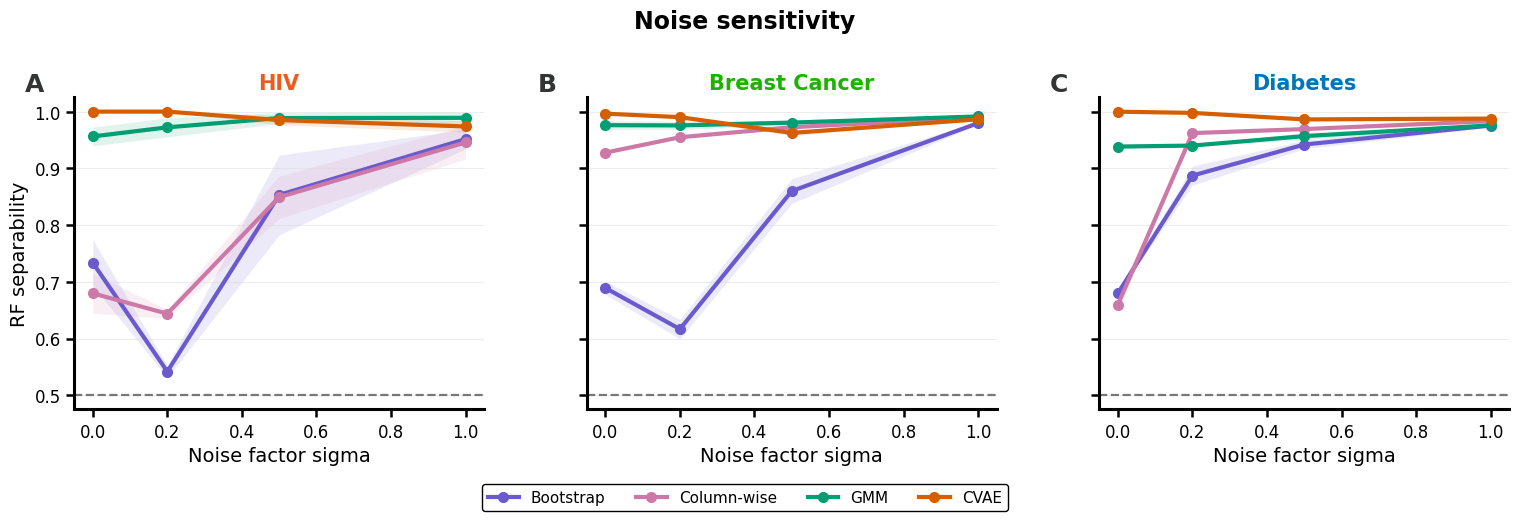

In [170]:
def plot_figure5_noise(noise_df):
    fig, axes = plt.subplots(1, 3, figsize=(15.6, 5.2), sharey=True, constrained_layout=False)
    legend_handles = []
    for ax, ds, panel in zip(axes, DATASET_ORDER, ["A", "B", "C"]):
        sub = noise_df[noise_df["dataset"] == ds]
        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("sigma")
            if m.empty:
                continue
            line, = ax.plot(m["sigma"], m["sep_mean"], marker="o", color=METHOD_COLORS[method], label=method,
                            linewidth=3.0, markersize=7)
            ax.fill_between(m["sigma"], m["sep_mean"] - m["sep_sd"], m["sep_mean"] + m["sep_sd"],
                            color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if ax is axes[0]:
                legend_handles.append(line)
        ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.6)
        ax.set_title(ds, color=DATASET_COLORS[ds], weight="bold")
        ax.set_xlabel("Noise factor σ")
        clean_axis(ax, grid_axis="y")
        ax.spines["left"].set_linewidth(2.2)
        ax.spines["bottom"].set_linewidth(2.2)
        ax.tick_params(width=1.8, length=6)
        add_panel_label(ax, panel)
    axes[0].set_ylabel("RF separability")
    fig.legend(legend_handles, METHOD_ORDER, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(METHOD_ORDER),
               frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
    fig.suptitle("Noise sensitivity", y=0.99, fontsize=17, weight="bold")
    fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.22, wspace=0.25)
    plt.show()


if "noise_df" in globals():
    plot_figure5_noise(noise_df)
else:
    display(Markdown(
        "**Figure 5 data not found.** Run the previous compute cell, then rerun this plot cell."
    ))


## Figure 6 - reverse feature ablation

Figure 6 asks whether discriminator separability depends on a small set of highly discriminating features. Features are ranked by real-vs-synthetic RF importance, the top-ranked features are removed progressively, and RF separability is recomputed over repeated splits.


In [171]:
def rank_discriminating_features(X_real, X_syn, seed=SEED):
    Xr, Xs = standardize_pair(X_real, X_syn)
    X = np.vstack([Xr, Xs])
    y = np.r_[np.zeros(len(Xr), dtype=int), np.ones(len(Xs), dtype=int)]
    rf = RandomForestClassifier(n_estimators=500, random_state=seed, class_weight="balanced", n_jobs=-1)
    rf.fit(X, y)
    return np.argsort(rf.feature_importances_)[::-1]


def ablation_grid(n_features, points=8):
    if n_features <= 2:
        return np.array([0], dtype=int)
    return np.unique(np.rint(np.linspace(0, n_features - 2, points)).astype(int))


def compute_reverse_ablation(datasets, seed=SEED, repeats=ABLATION_REPEATS, cvae_epochs=CVAE_EPOCHS):
    rows = []
    for ds in DATASET_ORDER:
        data = datasets[ds]
        X_real = np.asarray(data["X"], dtype=np.float32)
        y_real = np.asarray(data["y"], dtype=int)
        grid = ablation_grid(X_real.shape[1])
        for method in METHOD_ORDER:
            print(f"[ablation] {ds} - {method}")
            X_syn, y_syn = sample_synthetic(ds, data, method, seed=seed, cvae_epochs=cvae_epochs)
            ranking = rank_discriminating_features(X_real, X_syn, seed=seed)
            for n_removed in grid:
                keep = ranking[int(n_removed):]
                vals = [one_run_origin_auc(X_real[:, keep], y_real, np.asarray(X_syn)[:, keep], y_syn,
                                           seed=seed + 1009*r + 13*METHOD_ORDER.index(method))
                        for r in range(repeats)]
                rows.append({"dataset": ds, "method": method, "n_features_removed": int(n_removed),
                             "n_features_retained": int(len(keep)), "auc_mean": float(np.mean(vals)),
                             "auc_sd": float(np.std(vals)), "auc_values": vals})
    return pd.DataFrame(rows)


# Figure 6 data: computed automatically using the selected RUN_MODE.
ablation_df = compute_reverse_ablation(datasets)
display(ablation_df.head())


[ablation] HIV - Bootstrap
[ablation] HIV - Column-wise
[ablation] HIV - GMM
[ablation] HIV - CVAE
Epoch    1 | train loss=64.0298 recon=63.9487 kl=0.1622 | val loss=78.9202 recon=78.8401 kl=0.1601
Epoch   10 | train loss=60.1713 recon=59.4436 kl=1.4555 | val loss=75.1542 recon=74.1762 kl=1.9560
[ablation] Breast Cancer - Bootstrap
[ablation] Breast Cancer - Column-wise
[ablation] Breast Cancer - GMM
[ablation] Breast Cancer - CVAE
Epoch    1 | train loss=29.2989 recon=29.2293 kl=0.1391 | val loss=26.3287 recon=26.2282 kl=0.2010
Epoch   10 | train loss=14.8557 recon=12.6581 kl=4.3952 | val loss=12.9539 recon=10.9737 kl=3.9604
[ablation] Diabetes - Bootstrap
[ablation] Diabetes - Column-wise
[ablation] Diabetes - GMM
[ablation] Diabetes - CVAE
Epoch    1 | train loss=8.1590 recon=8.1175 kl=0.0829 | val loss=9.6845 recon=9.6289 kl=0.1111
Epoch   10 | train loss=5.3704 recon=4.0312 kl=2.6785 | val loss=5.9454 recon=4.2223 kl=3.4460


,dataset,method,n_features_removed,n_features_retained,auc_mean,auc_sd,auc_values
0,HIV,Bootstrap,0,63,0.741336,0.054045,"[0.6862003780718336, 0.7230623818525519, 0.814..."
1,HIV,Bootstrap,9,54,0.752048,0.054188,"[0.7051039697542534, 0.723062381852552, 0.8279..."
2,HIV,Bootstrap,17,46,0.768431,0.036712,"[0.7315689981096408, 0.7551984877126654, 0.818..."
3,HIV,Bootstrap,26,37,0.778513,0.039999,"[0.7353497164461247, 0.7684310018903592, 0.831..."
4,HIV,Bootstrap,35,28,0.779773,0.034105,"[0.7542533081285444, 0.7570888468809074, 0.827..."


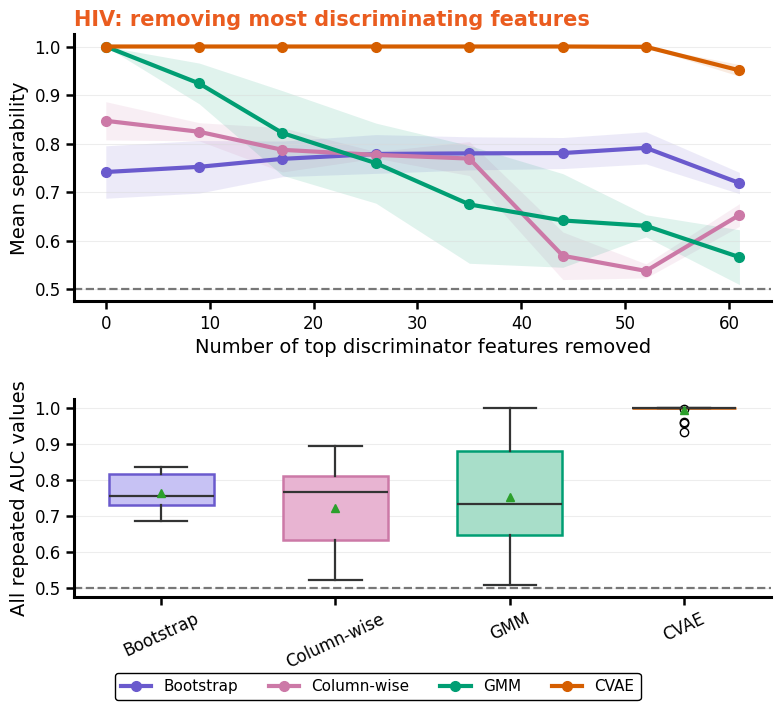

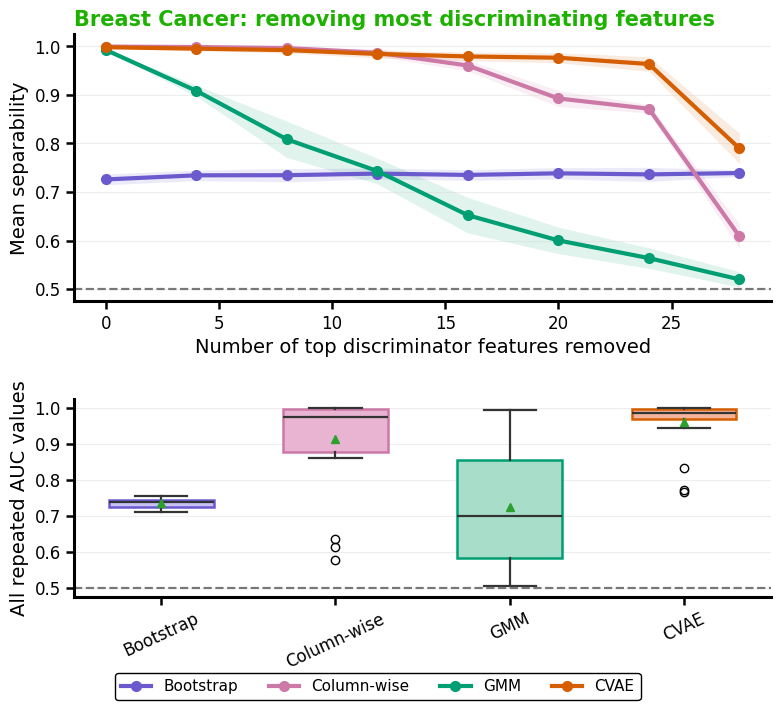

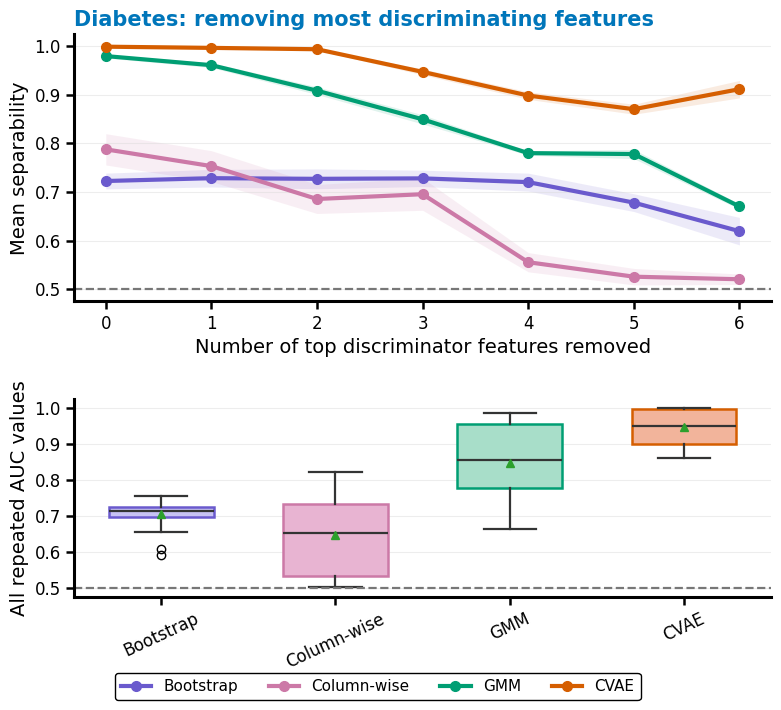

In [172]:
def _flat_values(series):
    vals = []
    for item in series:
        vals.extend(item if isinstance(item, (list, tuple, np.ndarray)) else [item])
    return np.asarray(vals, dtype=float)


def plot_figure6_ablation(ablation_df):
    for ds in DATASET_ORDER:
        sub = ablation_df[ablation_df["dataset"] == ds]
        if sub.empty:
            continue
        fig = plt.figure(figsize=(8.2, 7.4), constrained_layout=False)
        gs = fig.add_gridspec(2, 1, height_ratios=[1.35, 1.0])
        ax_curve = fig.add_subplot(gs[0, 0])
        ax_box = fig.add_subplot(gs[1, 0], sharey=ax_curve)
        box_values, box_labels = [], []
        legend_handles = []
        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("n_features_removed")
            if m.empty:
                continue
            line, = ax_curve.plot(m["n_features_removed"], m["auc_mean"], color=METHOD_COLORS[method], marker="o",
                                  label=method, linewidth=3.0, markersize=7)
            ax_curve.fill_between(m["n_features_removed"], m["auc_mean"] - m["auc_sd"], m["auc_mean"] + m["auc_sd"],
                                  color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            legend_handles.append(line)
            box_values.append(_flat_values(m["auc_values"]))
            box_labels.append(method)
        ax_curve.axhline(0.5, color="#777777", linestyle="--", linewidth=1.6)
        ax_curve.set_title(f"{ds}: removing most discriminating features", color=DATASET_COLORS[ds], weight="bold", loc="left")
        ax_curve.set_xlabel("Number of top discriminator features removed")
        ax_curve.set_ylabel("Mean separability")
        clean_axis(ax_curve, grid_axis="y")
        ax_curve.spines["left"].set_linewidth(2.2)
        ax_curve.spines["bottom"].set_linewidth(2.2)
        ax_curve.tick_params(width=1.8, length=6)

        bp = ax_box.boxplot(box_values, tick_labels=box_labels, patch_artist=True, showmeans=True, widths=0.60)
        for patch, method in zip(bp["boxes"], box_labels):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.8)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.6)
        ax_box.axhline(0.5, color="#777777", linestyle="--", linewidth=1.6)
        ax_box.set_ylabel("All repeated AUC values")
        ax_box.tick_params(axis="x", rotation=25, width=1.8, length=6)
        clean_axis(ax_box, grid_axis="y")
        ax_box.spines["left"].set_linewidth(2.2)
        ax_box.spines["bottom"].set_linewidth(2.2)

        fig.legend(legend_handles, [h.get_label() for h in legend_handles], loc="lower center", bbox_to_anchor=(0.5, 0.01),
                   ncol=len(legend_handles), frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
        fig.subplots_adjust(left=0.13, right=0.98, top=0.92, bottom=0.16, hspace=0.42)
        plt.show()


if "ablation_df" in globals():
    plot_figure6_ablation(ablation_df)
else:
    display(Markdown(
        "**Figure 6 data not found.** Run the previous compute cell, then rerun this plot cell."
    ))


### Figure 6A-C - all datasets

Compact three-panel version of the reverse feature ablation analysis. Panels A-C correspond to HIV, breast cancer, and diabetes, with the x-axis normalized to the percentage of top discriminator-ranked features removed so datasets with different feature counts remain visually comparable.


In [ ]:
def plot_figure6_ablation_ac(ablation_df):
    """Compact Figure 6 panel: A-C show reverse ablation plus repeated-run boxplots."""
    fig = plt.figure(figsize=(13.4, 7.0), constrained_layout=False)
    gs = fig.add_gridspec(2, len(DATASET_ORDER), height_ratios=[1.35, 0.95])
    curve_axes = [fig.add_subplot(gs[0, i]) for i in range(len(DATASET_ORDER))]
    box_axes = [fig.add_subplot(gs[1, i], sharey=curve_axes[0]) for i in range(len(DATASET_ORDER))]

    legend_handles = []
    for panel_idx, (ax_curve, ax_box, ds) in enumerate(zip(curve_axes, box_axes, DATASET_ORDER)):
        sub = ablation_df[ablation_df["dataset"] == ds]
        box_values, box_labels = [], []
        if sub.empty:
            ax_curve.set_visible(False)
            ax_box.set_visible(False)
            continue

        for method in METHOD_ORDER:
            m = sub[sub["method"] == method].sort_values("n_features_removed")
            if m.empty:
                continue
            n_removed = m["n_features_removed"]
            line, = ax_curve.plot(n_removed, m["auc_mean"], color=METHOD_COLORS[method], marker="o",
                                  linewidth=2.35, markersize=5.2, label=method)
            ax_curve.fill_between(n_removed, m["auc_mean"] - m["auc_sd"], m["auc_mean"] + m["auc_sd"],
                                  color=METHOD_COLORS[method], alpha=0.12, linewidth=0)
            if panel_idx == 0:
                legend_handles.append(line)
            box_values.append(_flat_values(m["auc_values"]))
            box_labels.append(method)

        ax_curve.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_curve.set_title(ds, color=DATASET_COLORS[ds], weight="semibold", pad=8, fontsize=13)
        ax_curve.text(-0.13, 1.08, chr(ord("A") + panel_idx), transform=ax_curve.transAxes,
                      fontsize=15, weight="bold", va="top", ha="left")
        max_removed = int(sub["n_features_removed"].max())
        ax_curve.set_xlim(-1, max_removed + 1)
        ax_curve.set_xlabel("Features removed")
        clean_axis(ax_curve, grid_axis="y")
        ax_curve.spines["left"].set_linewidth(1.8)
        ax_curve.spines["bottom"].set_linewidth(1.8)
        ax_curve.tick_params(width=1.4, length=5)

        bp = ax_box.boxplot(box_values, tick_labels=box_labels, patch_artist=True, showmeans=True, widths=0.60)
        for patch, method in zip(bp["boxes"], box_labels):
            patch.set_facecolor(METHOD_PASTELS[method])
            patch.set_edgecolor(METHOD_COLORS[method])
            patch.set_linewidth(1.55)
        for key in ["whiskers", "caps", "medians", "means"]:
            for artist in bp.get(key, []):
                artist.set_color(NEUTRAL)
                artist.set_linewidth(1.25)
        ax_box.axhline(0.5, color="#777777", linestyle="--", linewidth=1.25)
        ax_box.tick_params(axis="x", rotation=25, labelsize=9.0, width=1.4, length=5)
        clean_axis(ax_box, grid_axis="y")
        ax_box.spines["left"].set_linewidth(1.8)
        ax_box.spines["bottom"].set_linewidth(1.8)

    curve_axes[0].set_ylabel("AUC")
    box_axes[0].set_ylabel("AUC")
    for ax in curve_axes[1:] + box_axes[1:]:
        ax.tick_params(labelleft=False)

    y_values = []
    for _, row in ablation_df.iterrows():
        y_values.extend([row["auc_mean"] - row["auc_sd"], row["auc_mean"] + row["auc_sd"]])
        y_values.extend(row.get("auc_values", []))
    y_min = max(0.45, np.nanmin(y_values) - 0.03)
    y_max = min(1.02, np.nanmax(y_values) + 0.03)
    for ax in curve_axes + box_axes:
        if ax.get_visible():
            ax.set_ylim(y_min, y_max)

    handles = legend_handles[:len(METHOD_ORDER)]
    fig.legend(handles, [h.get_label() for h in handles], loc="lower center",
               bbox_to_anchor=(0.5, 0.01), ncol=len(handles), frameon=True,
               facecolor="white", edgecolor="black", framealpha=1.0, borderpad=0.55)
    fig.suptitle("Reverse feature ablation", y=0.98, fontsize=15, weight="semibold")
    fig.subplots_adjust(left=0.075, right=0.99, top=0.88, bottom=0.20, wspace=0.18, hspace=0.35)
    plt.show()


if "ablation_df" in globals():
    plot_figure6_ablation_ac(ablation_df)
else:
    display(Markdown(
        "**Figure 6 data not found.** Run the previous compute cell, then rerun this plot cell."
    ))


## Suggested export cell

Use this only after the notebook visuals are final. It keeps exports separate from the exploratory cells above.


In [173]:
# Example:
# out_dir = repo_root / "figures" / "main_v2"
# out_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_dir / "figure_name.svg", bbox_inches="tight")
# fig.savefig(out_dir / "figure_name.png", dpi=300, bbox_inches="tight")
